Adınız: Melek
Soyadınız: ÇATAL
Okul Numaranız: 2212721039
GitHub Repo Bağlantısı:  https://github.com/melekcatal/CNN_Siniflandirma.git

Sıfırdan tanımlanmış basit bir Convolutional Neural Network (CNN)
mimarisi kullanılarak görüntü sınıflandırması yapılmıştır.
Bu aşamada transfer learning kullanılmamış, model tamamen kendi veri setim
üzerinde eğitilmiştir.

In [26]:
# Veri setinin bulunduğu Google Drive klasörüne erişim sağlanır.

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
# Model oluşturma, eğitim, değerlendirme ve görselleştirme için gerekli kütüphaneler içe aktarılır.

import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np


In [28]:
# Eğitim, doğrulama ve test veri setlerinin bulunduğu klasör yolları tanımlanır.

train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'


In [52]:
# Modelin giriş görüntü boyutu, batch size ve epoch sayısı belirlenmiştir.

Img_Size   = 128
Batch_Size = 16
Epochs     = 15


In [53]:
# Görüntüler 0–1 aralığına ölçeklenmiştir. Bu modelde veri artırımı uygulanmamıştır.

train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)


In [54]:
# Görüntüler klasör yapısına göre otomatik olarak etiketlenerek yüklenir.
# Test setinde karışıklık matrisi için sıralama korunmuştur.

train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)


Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.


In [55]:
# Modelin öğrendiği sınıf isimleri doğrulanır.

class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)


Sınıf etiketleri: ['fare_disi', 'kelebek']


In [56]:
# Basit ve sıralı bir CNN mimarisi tanımlamak için Sequential modeli kullanılır.
model = Sequential()

# Conv1 + MaxPool
# İlk konvolüsyon katmanı ile temel kenar ve doku özellikleri çıkarılır.
model.add(Conv2D(filters=16, kernel_size=2, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

# Conv2 + MaxPool
# Daha karmaşık görsel özelliklerin öğrenilmesi amaçlanır.
model.add(Conv2D(filters=32, kernel_size=2, padding='same',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# Conv3 + MaxPool
# Derinlik arttırılarak daha ayırt edici özellikler elde edilir.
model.add(Conv2D(filters=64, kernel_size=2, padding='same',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# Flatten
# Özellik haritaları tam bağlantılı katmanlara uygun hale getirilir.
model.add(Flatten())

# Fully Connected + Dropout
# Öğrenilen özellikler kullanılarak sınıflandırma yapılır ve aşırı öğrenme azaltılır.
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Çıkış katmanı (2 sınıf – binary)
# İkili sınıflandırma problemi için sigmoid aktivasyon kullanılmıştır.
model.add(Dense(1, activation='sigmoid'))

# Modelin katman yapısı ve parametre sayıları görüntülenir.
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,107,953 (8.04 MB)

 Trainable params: 2,107,953 (8.04 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# İkili sınıflandırma için uygun kayıp fonksiyonu ve optimizasyon yöntemi seçilmiştir.

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


In [58]:
# Doğrulama kaybı en düşük olan model diske kaydedilir.

checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)


In [59]:
# Model belirlenen epoch sayısı boyunca eğitilir ve doğrulama performansı izlenir.

history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.5146 - loss: 1.1230
Epoch 1: val_loss improved from inf to 0.69043, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5128 - loss: 1.1188 - val_accuracy: 0.5833 - val_loss: 0.6904
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.5535 - loss: 0.6848
Epoch 2: val_loss did not improve from 0.69043
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 873ms/step - accuracy: 0.5512 - loss: 0.6842 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.5024 - loss: 0.6843
Epoch 3: val_loss improved from 0.69043 to 0.66919, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 871ms/step - accuracy: 0.5099 - loss: 0.6820 - val_accuracy: 0.5833 - val_loss: 0.6692
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.7516 - loss: 0.6448
Epoch 4: val_loss improved from 0.66919 to 0.64195, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━

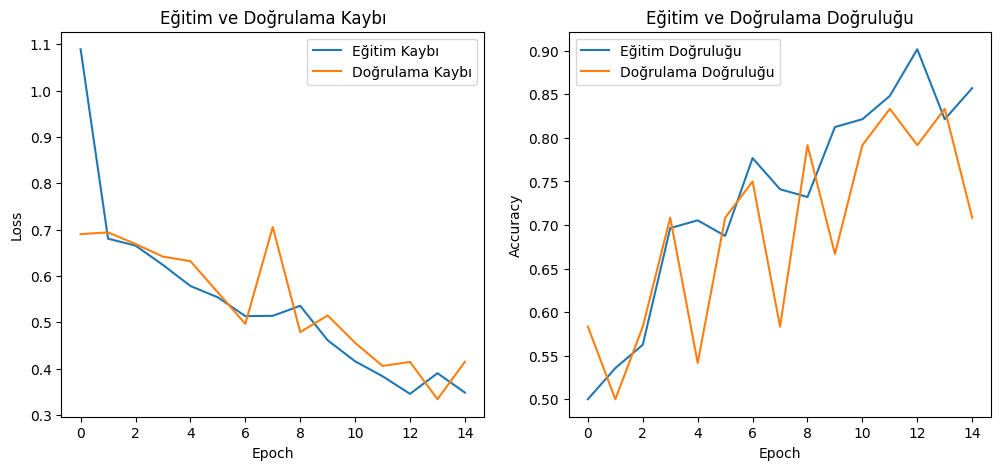

In [60]:
# Modelin öğrenme süreci grafiklerle analiz edilir.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend()

plt.show()


In [61]:
# Eğitilen modelin test verisi üzerindeki başarımı ölçülür.

test_score = model.evaluate(test_batches, verbose=1)
print("\nTest doğruluğu:", test_score[1])


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.7083 - loss: 0.5879

Test doğruluğu: 0.75


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step


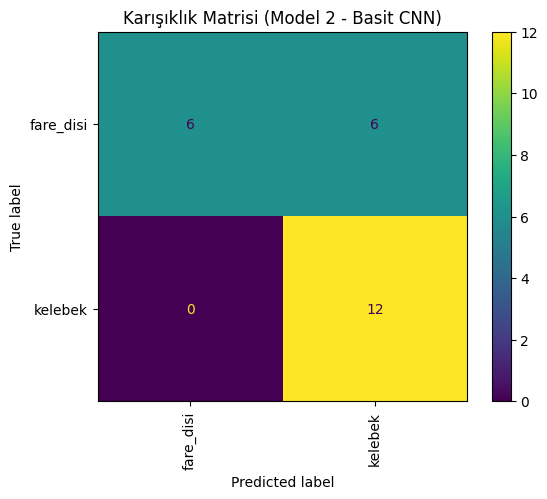

In [62]:
# Modelin sınıfları ne kadar doğru ayırt ettiğini görmek için karışıklık matrisi oluşturulmuştur.

y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()
